# Plotting Code for EXP2: Hidden State Ablation Study

In [1]:
import numpy as np
import json
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")

In [38]:
#load JSON results

FILENAMES = {
    "hidden_state" : r"data\eval_results\alpaca\hidden_state_res.json",
    "fixed": r"data\eval_results\alpaca\fixed_res.json",
    "ULS": r"data\eval_results\alpaca\ULS_res.json",
}
alphas = [2,4,6,10]
ULS_layers = [24,12,8,6,4]
data_dict = {}
for key in FILENAMES:
    with open(FILENAMES[key], 'r') as f:
        data_dict[key] = json.load(f)

print(data_dict["hidden_state"].keys())
print(data_dict["hidden_state"]["HS_2"].keys())

dict_keys(['HS_2', 'HS_4', 'HS_6', 'HS_10'])
dict_keys(['loss', 'rougeL', 'perc_skip'])


In [39]:
HS_rouge = [data_dict["hidden_state"][f"HS_{i}"]["rougeL"] for i in alphas]
HS_loss = [data_dict["hidden_state"][f"HS_{i}"]["loss"] for i in alphas]
HS_perc_skip = [data_dict["hidden_state"][f"HS_{i}"]["perc_skip"] for i in alphas]
HS_layer_use = [(1-s)*24 for s in HS_perc_skip]

fixed_rouge = [data_dict["fixed"][f"fixed_{i}"]["rougeL"] for i in alphas]
fixed_loss = [data_dict["fixed"][f"fixed_{i}"]["loss"] for i in alphas]
fixed_perc_skip = [data_dict["fixed"][f"fixed_{i}"]["perc_skip"] for i in alphas]
fixed_layer_use = [(1-s)*24 for s in fixed_perc_skip]

ULS_rouge = [data_dict["ULS"][f"ULS_{i}"]["rougeL"] for i in ULS_layers]
ULS_loss = [data_dict["ULS"][f"ULS_{i}"]["loss"] for i in ULS_layers]
ULS_perc_skip = [data_dict["ULS"][f"ULS_{i}"]["perc_skip"] for i in ULS_layers]
ULS_layer_use = [(1-s)*24 for s in ULS_perc_skip]

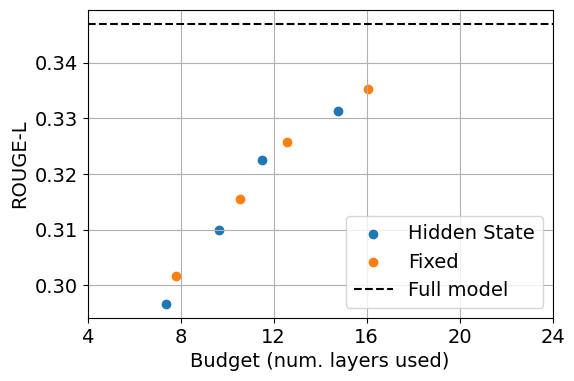

In [41]:
#plot RougeL against avg layer use
plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
plt.scatter(HS_layer_use, HS_rouge, label="Hidden State")
plt.scatter(fixed_layer_use, fixed_rouge, label="Fixed")
plt.axhline(y=data_dict["ULS"]["ULS_24"]["rougeL"], color=(0,0,0), linestyle='--',label='Full model')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()
#save as pdf
#plt.savefig(r"data\eval_results\alpaca\layer_use_rouge.pdf", bbox_inches='tight')


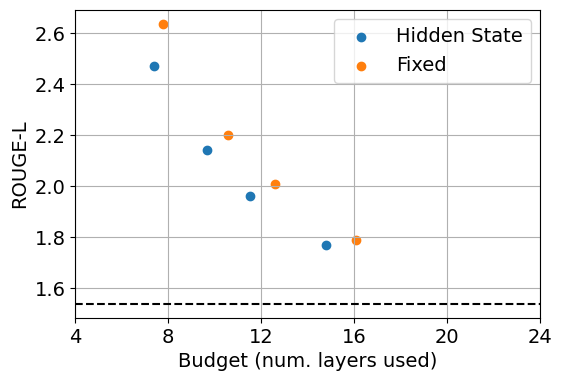

In [35]:
#plot Loss against avg layer use
plt.figure(figsize=(6, 4))
plt.rcParams.update({'font.size': 14})
plt.scatter(HS_layer_use, HS_loss, label="Hidden State")
plt.scatter(fixed_layer_use, fixed_loss, label="Fixed")
plt.axhline(y=data_dict["ULS"]["ULS_24"]["loss"], color=(0,0,0), linestyle='--')
plt.xlim(4,24)
plt.xticks(np.arange(4, 25, 4))
plt.grid()
plt.ylabel("ROUGE-L")
plt.xlabel("Budget (num. layers used)")
plt.legend()